In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully')

All libraries imported successfully


In [48]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip'

import io, zipfile, urllib.request

response = urllib.request.urlopen(url)
z = zipfile.ZipFile(io.BytesIO(response.read()))
df = pd.read_csv(z.open('bank.csv'), sep=';')

print(f'Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded successfully!
Shape: (4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [49]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [50]:
print('Statistical Summary:')
df.describe(include='all')

Statistical Summary:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,4521.000000,4521,4521,4521,4521,4521.000000,4521,4521,4521,4521.000000,4521,4521.000000,4521.000000,4521.000000,4521.000000,4521,4521
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,management,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,969,2797,2306,4445,NaN,2559,3830,2896,NaN,1398,NaN,NaN,NaN,NaN,3705,4000
mean,41.170095,NaN,NaN,NaN,NaN,1422.657819,NaN,NaN,NaN,15.915284,NaN,263.961292,2.793630,39.766645,0.542579,NaN,NaN
std,10.576211,NaN,NaN,NaN,NaN,3009.638142,NaN,NaN,NaN,8.247667,NaN,259.856633,3.109807,100.121124,1.693562,NaN,NaN
min,19.000000,NaN,NaN,NaN,NaN,-3313.000000,NaN,NaN,NaN,1.000000,NaN,4.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,69.000000,NaN,NaN,NaN,9.000000,NaN,104.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,444.000000,NaN,NaN,NaN,16.000000,NaN,185.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,49.000000,NaN,NaN,NaN,NaN,1480.000000,NaN,NaN,NaN,21.000000,NaN,329.000000,3.000000,-1.000000,0.000000,NaN,NaN


In [51]:
print('Missing Values:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Total missing: 0


Target Variable (y) Distribution:
y
no     4000
yes     521
Name: count, dtype: int64


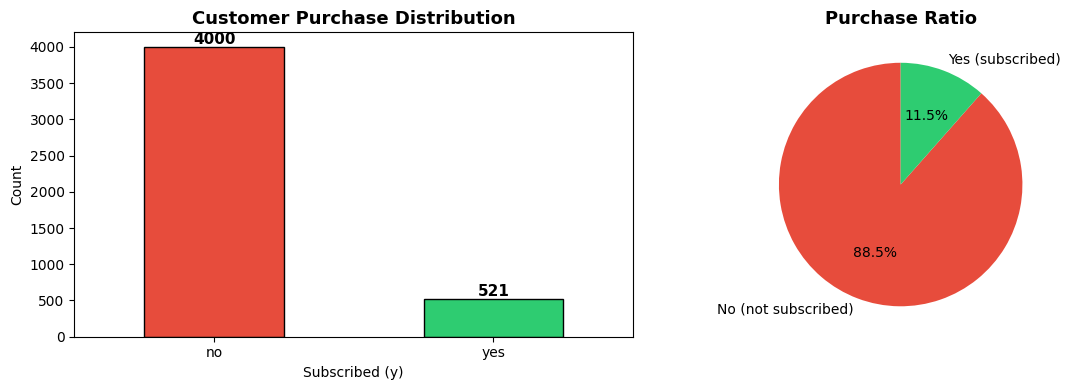

Plot saved!


In [52]:

print('Target Variable (y) Distribution:')
print(df['y'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#e74c3c', '#2ecc71']
df['y'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', rot=0)
axes[0].set_title('Customer Purchase Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

df['y'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
                             autopct='%1.1f%%', startangle=90,
                             labels=['No (not subscribed)', 'Yes (subscribed)'])
axes[1].set_title('Purchase Ratio', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

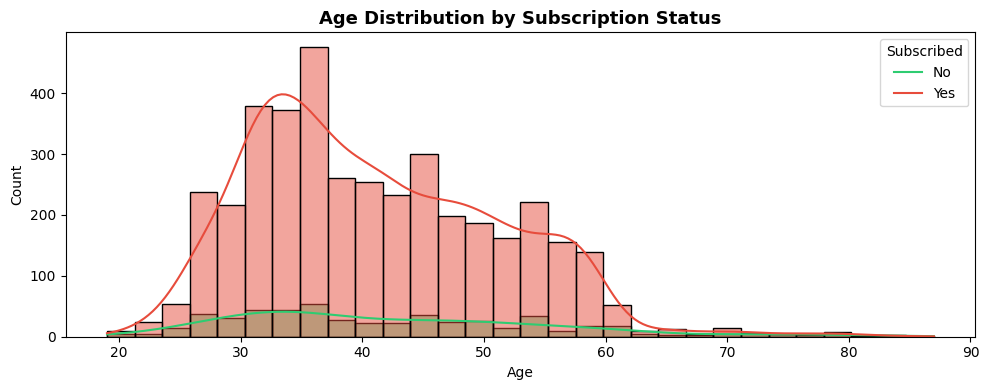

In [53]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='age', hue='y', bins=30, palette=['#e74c3c', '#2ecc71'], kde=True)
plt.title('Age Distribution by Subscription Status', fontsize=13, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Subscribed', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1200x500 with 0 Axes>

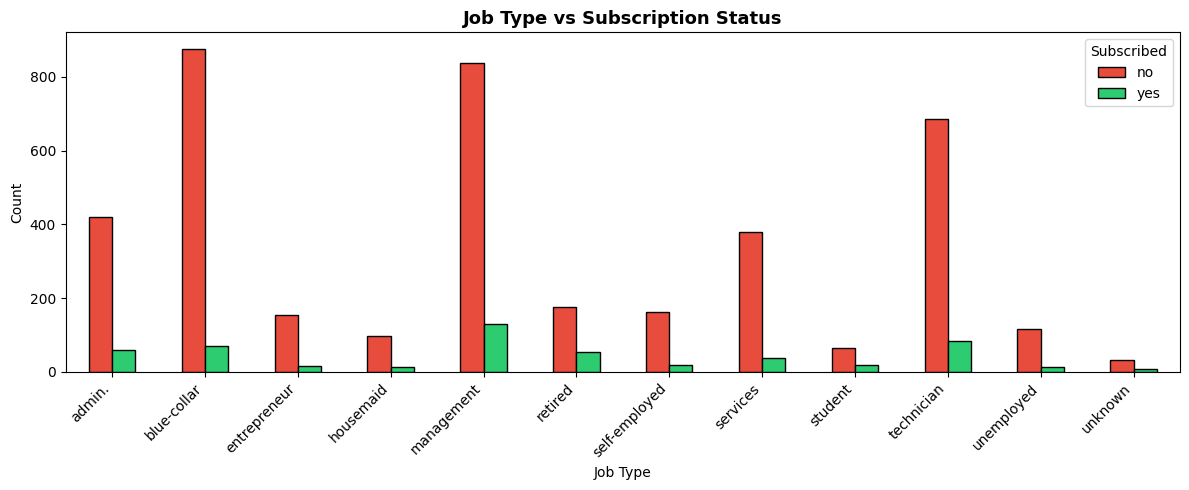

In [54]:
plt.figure(figsize=(12, 5))
job_sub = df.groupby(['job', 'y']).size().unstack()
job_sub.plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black', figsize=(12,5))
plt.title('Job Type vs Subscription Status', fontsize=13, fontweight='bold')
plt.xlabel('Job Type')
plt.ylabel('Count')
plt.legend(title='Subscribed')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('job_vs_subscription.png', dpi=150, bbox_inches='tight')
plt.show()

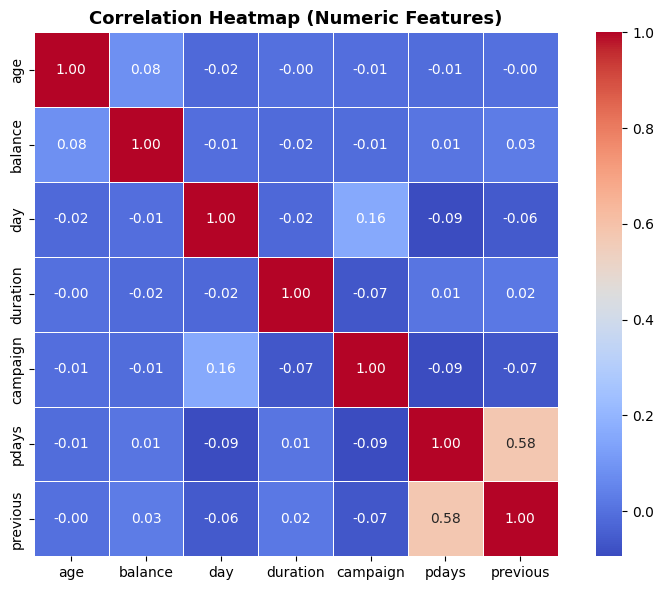

In [55]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap (Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
df_encoded = df.copy()
le = LabelEncoder()

categorical_cols = df_encoded.select_dtypes(include='object').columns
print('Categorical columns to encode:')
print(list(categorical_cols))

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print('\nEncoding complete!')
df_encoded.head()

Categorical columns to encode:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Encoding complete!


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,10,1,0,0,1787,0,0,0,19,10,79,1,-1,0,3,0
1,33,7,1,1,0,4789,1,1,0,11,8,220,1,339,4,0,0
2,35,4,2,2,0,1350,1,0,0,16,0,185,1,330,1,0,0
3,30,4,1,2,0,1476,1,1,2,3,6,199,4,-1,0,3,0
4,59,1,1,1,0,0,1,0,2,5,8,226,1,-1,0,3,0


In [57]:
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Feature columns: {list(X.columns)}')

Features shape: (4521, 16)
Target shape: (4521,)
Feature columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']


In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Data split complete!')
print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Data split complete!
Training samples: 3616
Testing samples:  905


In [59]:
dt_model = DecisionTreeClassifier(random_state=42, criterion='gini')
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'Decision Tree (Unpruned)')
print(f'Tree Depth: {dt_model.get_depth()}')
print(f'Number of Leaves: {dt_model.get_n_leaves()}')
print(f'Accuracy: {acc*100:.2f}%')

Decision Tree (Unpruned)
Tree Depth: 19
Number of Leaves: 309
Accuracy: 85.64%


In [60]:
dt_pruned = DecisionTreeClassifier(random_state=42, criterion='gini', max_depth=5, min_samples_split=20)
dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)
acc_pruned = accuracy_score(y_test, y_pred_pruned)

print(f'Decision Tree (Pruned — max_depth=5)')
print(f'Tree Depth: {dt_pruned.get_depth()}')
print(f'Number of Leaves: {dt_pruned.get_n_leaves()}')
print(f'Accuracy: {acc_pruned*100:.2f}%')

print(f'\nComparison:')
print(f'Unpruned Accuracy: {acc*100:.2f}%')
print(f'Pruned Accuracy:   {acc_pruned*100:.2f}%')

Decision Tree (Pruned — max_depth=5)
Tree Depth: 5
Number of Leaves: 22
Accuracy: 89.17%

Comparison:
Unpruned Accuracy: 85.64%
Pruned Accuracy:   89.17%


In [61]:
print('Classification Report (Pruned Model):')
print('='*55)
print(classification_report(y_test, y_pred_pruned, target_names=['No', 'Yes']))

Classification Report (Pruned Model):
              precision    recall  f1-score   support

          No       0.92      0.96      0.94       801
         Yes       0.55      0.34      0.42       104

    accuracy                           0.89       905
   macro avg       0.73      0.65      0.68       905
weighted avg       0.88      0.89      0.88       905



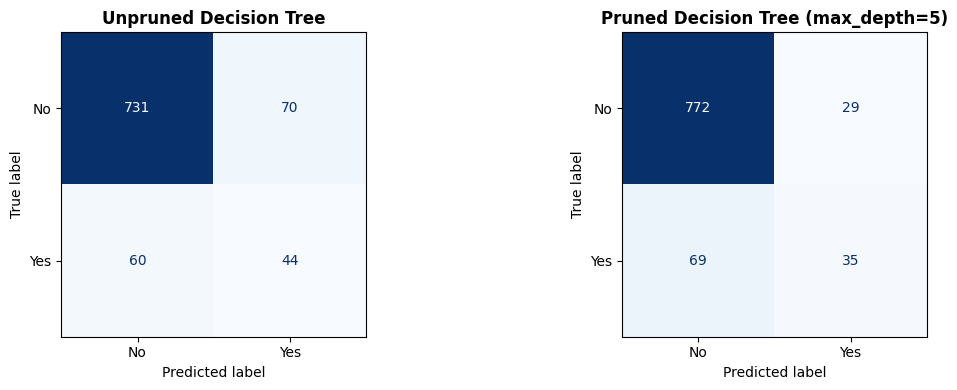

Confusion matrix saved!


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(axes,
                             [y_pred, y_pred_pruned],
                             ['Unpruned Decision Tree', 'Pruned Decision Tree (max_depth=5)']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved!')

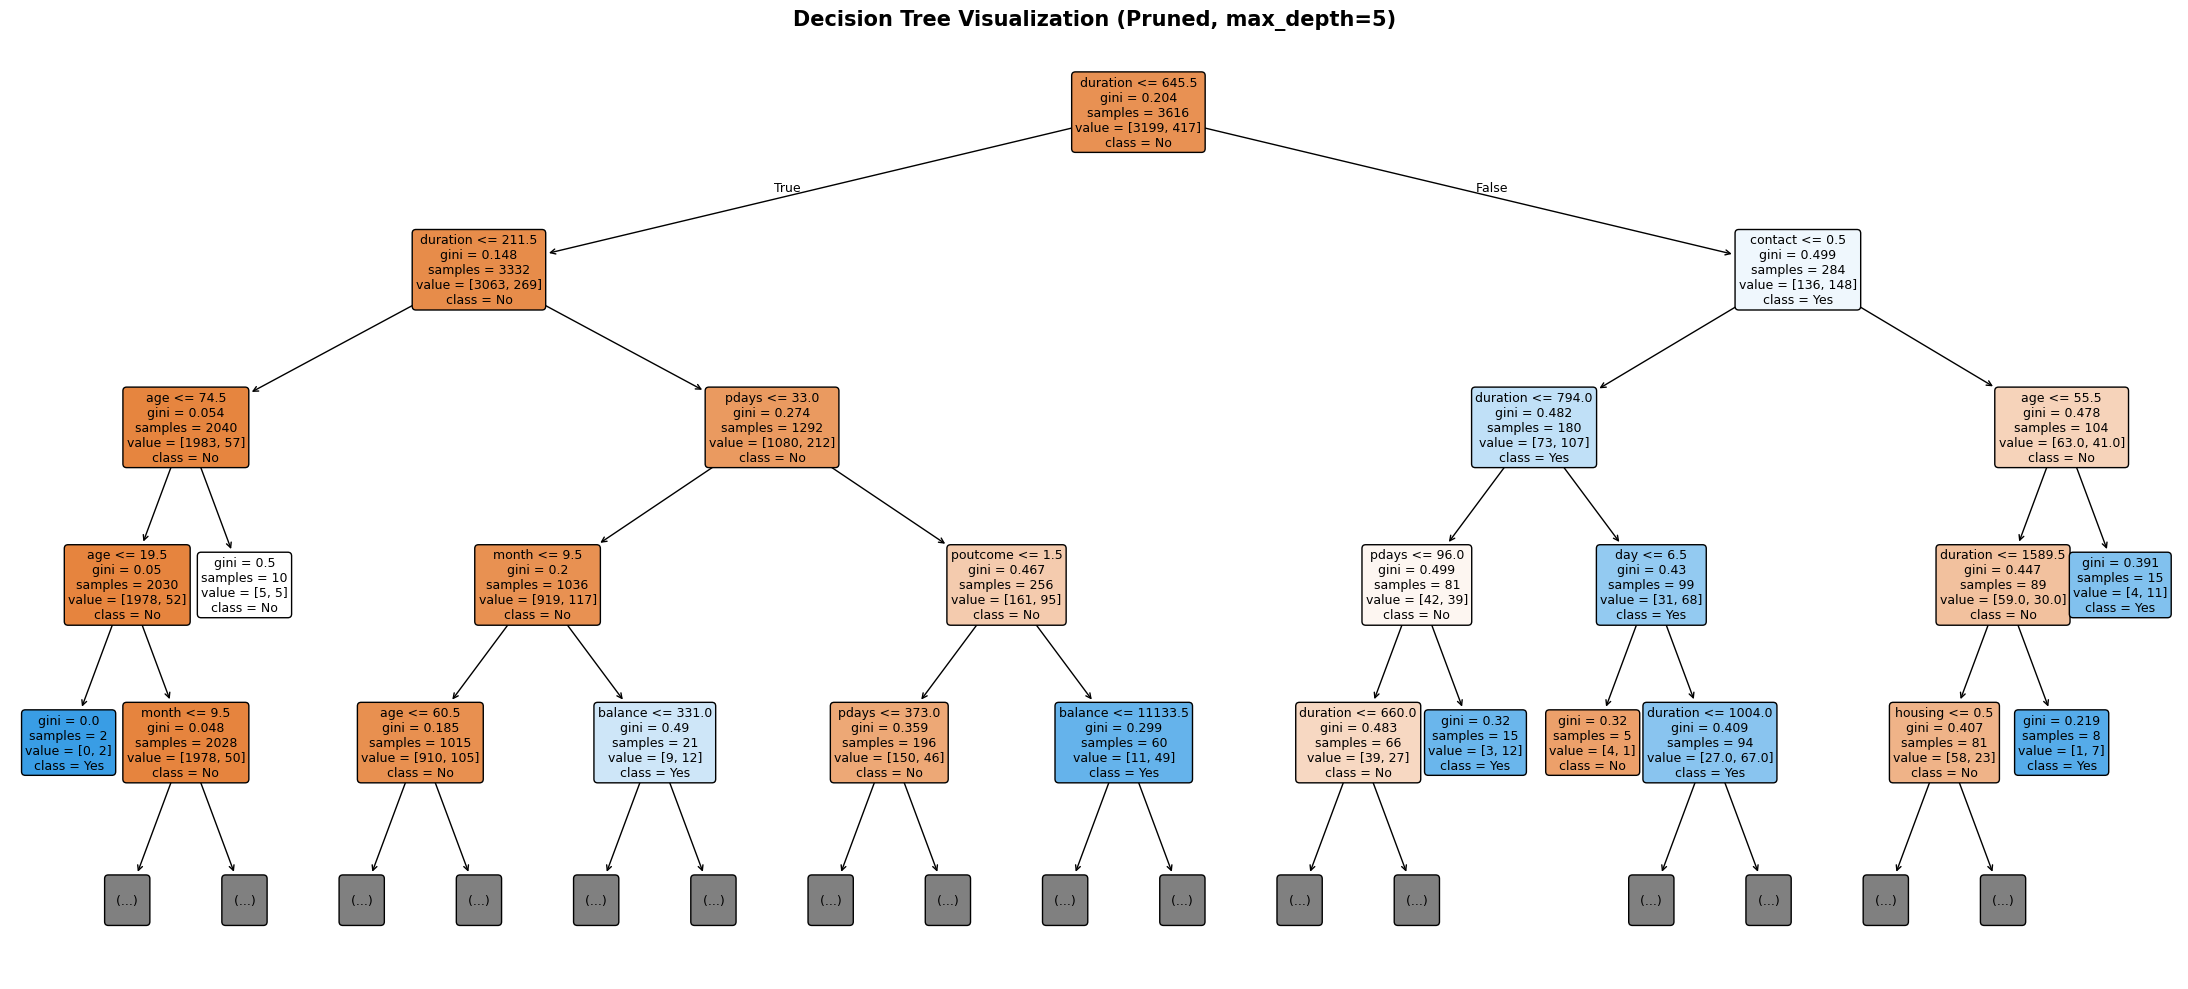

Decision tree visualization saved!


In [63]:
plt.figure(figsize=(22, 10))
plot_tree(
    dt_pruned,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=4
)
plt.title('Decision Tree Visualization (Pruned, max_depth=5)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print('Decision tree visualization saved!')

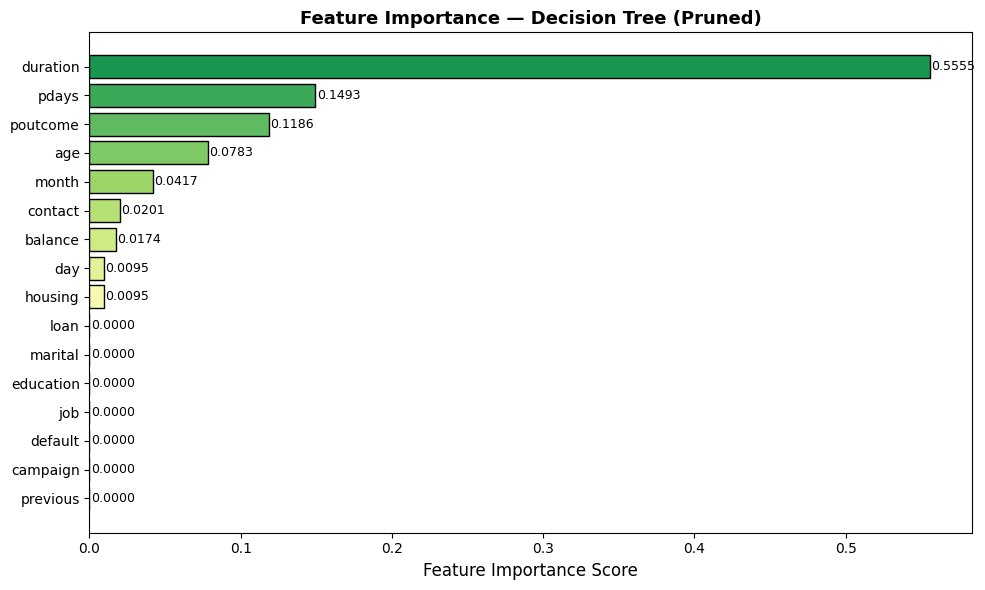


Top 5 Most Important Features:
duration    0.555508
pdays       0.149311
poutcome    0.118611
age         0.078317
month       0.041705
dtype: float64


In [64]:
importances = pd.Series(dt_pruned.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
bars = plt.barh(importances.index[::-1], importances.values[::-1], color=colors_fi, edgecolor='black')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Feature Importance — Decision Tree (Pruned)', fontsize=13, fontweight='bold')

for bar, val in zip(bars, importances.values[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 Most Important Features:')
print(importances.head())

In [65]:
print('TASK 3 — FINAL SUMMARY')

print(f'Dataset       : Bank Marketing (UCI ML Repository)')
print(f'Total Records : {df.shape[0]} | Features: {df.shape[1]-1}')
print(f'Train/Test    : 80% / 20% split')
print(f'Model         : Decision Tree Classifier (Gini Index)')

print(f'Unpruned Accuracy : {acc*100:.2f}%  (depth={dt_model.get_depth()}, leaves={dt_model.get_n_leaves()})')
print(f'Pruned Accuracy   : {acc_pruned*100:.2f}%  (depth={dt_pruned.get_depth()}, leaves={dt_pruned.get_n_leaves()})')

top_feat = importances.idxmax()
print(f'Top Feature   : "{top_feat}" (Importance: {importances.max():.4f})')

print()
print('Key Observations:')
print('Pruning improves generalization & reduces overfitting')
print('"duration" (call duration) is the strongest predictor')
print('Class imbalance (no >> yes) affects recall for Yes class')
print('Decision Trees offer high interpretability for business use')

print('Task 3 Completed Successfully! — Prodigy InfoTech Internship')

TASK 3 — FINAL SUMMARY
Dataset       : Bank Marketing (UCI ML Repository)
Total Records : 4521 | Features: 16
Train/Test    : 80% / 20% split
Model         : Decision Tree Classifier (Gini Index)
Unpruned Accuracy : 85.64%  (depth=19, leaves=309)
Pruned Accuracy   : 89.17%  (depth=5, leaves=22)
Top Feature   : "duration" (Importance: 0.5555)

Key Observations:
Pruning improves generalization & reduces overfitting
"duration" (call duration) is the strongest predictor
Class imbalance (no >> yes) affects recall for Yes class
Decision Trees offer high interpretability for business use
Task 3 Completed Successfully! — Prodigy InfoTech Internship
